In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.tsa.api as tsa
import statsmodels.api as sm
from patsy import dmatrices

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse


# DATA PREP

In [2]:
data = pd.read_csv('Unicum_last_flagged.csv',skiprows=[0,1,2],sep='\s+',on_bad_lines='skip')

aliases = {
        '0219+428': '3C66A',
        '0316+41': '3C84',
        '0355+508': 'NRAO150',
        '0851+202': 'OJ287',
        '1226+023': '3C273',
        '1253-055': '3C279',
        '1641+399': '3C345',
        '2200+420': 'BLLAC',
        '2251+158': '3C454.3',
        'Mrk501': 'Mrk501',
        '3c207': '3c207',
        'PKS1222+216': '1221+21',
        'BS0846+513': '0846+513',
        'CTA102': '2230+114'
    }

def replace_aliases(data, aliases):
    data_copy = data.copy()
    for original, alias in aliases.items():
        data_copy['Name'] = data_copy['Name'].replace(original, alias)
    return data_copy

data_with_aliases_replaced = replace_aliases(data, aliases)


print(data['Name'].unique())
len(data_with_aliases_replaced['Name'].unique())

['1221+21' '3C147' 'MRK421' 'NESCI' '3C84' 'MRK501' '0948+0022'
 'S41849+67' '1510-089' 'BS0846+513' 'PKS1346-112' '3C273' '1156+295'
 '1219+285' '1354+195' '1606+105' '0716+714' '1730-130' '1741-038'
 '1611+343' '1633+382' '3C345' '0954+658' '0836+710' '2223-052' '2230+114'
 '3C454.3' '2344+092' 'NRAO150' '0235+164' '0336-019' '0420-014'
 '0528+134' 'DR21' '3C279' '3C66A' '1334-127' '1807+698' 'BLLAC'
 '0440-003' '0736+017' '0735+178' '0827+243' 'OJ287' '0829+046'
 'TXS0536+145' '3C207' '1055+567' '3C380' 'CTA102' '0846+513' 'B20218+35'
 'SgrA' 'PG1553+113' '0323+342' '1227+25' '2007+77' 'J0902+0443'
 'S40444+63' 'TXS0506+056' '1ES1959+650' '1ES2344+514' 'PKS1222+216'
 'PKS1441+25' 'PKSJ1153-1105' '1830-211' 'MHz' 'Mrk501' '3c207' '***']


67

In [3]:
data_NEW = pd.read_csv('new_SRT_data.txt',skiprows=1,sep='\s+',on_bad_lines='skip')
data_NEW['Flux']= (data_NEW['flux_0']+data_NEW['flux_1'])/2
data_NEW['e_Flux']= abs((data_NEW['e_flux_0']+data_NEW['e_flux_1'])/2)
source_u=data_NEW['Name'].unique()
source_u

array(['PKS1222+216', '3C273', '3C279', '1334-127', '1354+195',
       'PKS1441+25', '1510-089', 'PG1553+113', '1606+105', '1830-211',
       '1730-130', '1741-038', '1611+343', '1633+382', '3C345', 'Mrk501',
       '1807+698', 'BLLAC', '1ES1959+650', '2223-052', '2230+114',
       '3C454.3', '3C380', '3C66A', '3C84', '2344+092', '0235+164',
       'NRAO150', '0336-019', '0420-014', '0440-003', 'TXS0506+056',
       '1ES2344+514', '0528+134', '0716+714', '0736+017', '0735+178',
       '0827+243', '0829+046', '3c207', '0836+710', 'OJ287', '0954+658',
       'MRK421', '1156+295', '1219+285'], dtype=object)

In [4]:
def get_source_data(data, source):
    source_data = data[data['Name'] == source]
    return source_data

# Plotting individual sources

In [5]:
source = '1611+343'
source_data = get_source_data(data, source)

print(source_data)

          Name  HHMMSS         #MJD     Freq     Elev    Flux  e_Flux
100   1611+343  132134  55916.55859   5125.0  43.5270  2.9427  0.0646
192   1611+343  141726  55916.59766   8305.0  33.7975  2.8390  0.1488
242   1611+343  102404  55973.43750   5125.0  35.3874  3.1047  0.1079
274   1611+343  091710  56002.39062   5125.0  27.6757  3.1076  0.0947
357   1611+343  073228  56037.31641   5125.0  22.3159  3.0908  0.1106
...        ...     ...          ...      ...      ...     ...     ...
9329  1611+343  190508  60205.79693   8305.0  49.2072  3.0474  0.0414
9365  1611+343  024731  59997.11798  24100.0  59.2399  2.1172  0.0978
9466  1611+343  185526  60115.79016  24100.0  58.4948  1.9045  0.1256
9529  1611+343  140955  60178.59187  24100.0  51.7543  1.9179  0.1979
9584  1611+343  140014  60205.58515  24100.0  68.6995  1.9746  0.1180

[248 rows x 7 columns]


In [6]:
source = '1611+343'
source_data_new = get_source_data(data_NEW, source)
print(source_data_new)

         Name  HHMMSS         #MJD     Freq     Elev    Amp_0    Amp_1  \
12   1611+343  102953  60712.43930   4825.0  42.4534  43.1239  37.6129   
49   1611+343   83945  60735.36283   4825.0  46.1805  25.7086  28.7159   
104  1611+343   32604  60712.14476  24600.0  53.3095   6.1192   6.7610   
177  1611+343   14040  60736.07156  24600.0  51.1866   4.2629   4.7308   
248  1611+343  215708  60787.91634  24600.0  47.5414   4.0762   4.3948   
255  1611+343   43637  60788.19398   4825.0  52.8307  41.1294  44.8094   

     e_Amp_0  e_Amp_1  flux_0  flux_1  e_flux_0  e_flux_1     Flux   e_Flux  
12    0.1155   0.1021  2.9853  3.0015    0.0270    0.0273  2.99340  0.02715  
49    0.0945   0.0953  2.1198  2.3391    0.0184    0.0202  2.22945  0.01930  
104   0.1120   0.0549  1.3755  1.3890    0.0281    0.0167  1.38225  0.02240  
177   0.1002   0.0545  1.3268  1.2740    0.0377    0.0243  1.30040  0.03100  
248   0.0847   0.0625  1.2249  1.2549    0.0290    0.0232  1.23990  0.02610  
255   0.1120 

# PLOT

C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_27700\3749841213.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_data['Freq'] = pd.to_numeric(source_data['Freq'], errors='coerce')
C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_27700\3749841213.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  source_data['#MJD'] = pd.to_numeric(source_data['#MJD'], errors='coerce')
C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_27700\3749841213.py:4: SettingWithCopyWarning: 
A value is trying to be set on 

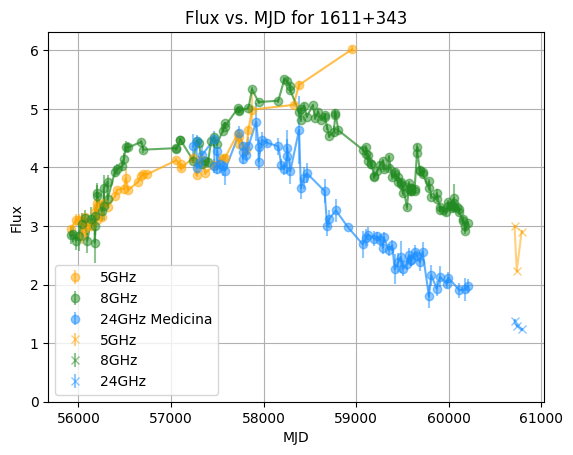

In [7]:

# Ensure 'Freq', '#MJD', 'Flux', and 'e_Flux' columns are numeric
source_data['Freq'] = pd.to_numeric(source_data['Freq'], errors='coerce')
source_data['#MJD'] = pd.to_numeric(source_data['#MJD'], errors='coerce')
source_data['Flux'] = pd.to_numeric(source_data['Flux'], errors='coerce')
source_data['e_Flux'] = pd.to_numeric(source_data['e_Flux'], errors='coerce')
source_data_new['Freq'] = pd.to_numeric(source_data_new['Freq'], errors='coerce')
source_data_new['#MJD'] = pd.to_numeric(source_data_new['#MJD'], errors='coerce')
source_data_new['Flux'] = pd.to_numeric(source_data_new['Flux'], errors='coerce')
source_data_new['e_Flux'] = pd.to_numeric(source_data_new['e_Flux'], errors='coerce')


f_data_5 =  source_data[(source_data['Freq'] >= 4000) & (source_data['Freq'] <= 7000)]
f_data_8 =  source_data[(source_data['Freq'] >= 7000) & (source_data['Freq'] <= 9000)]
f_data_20 =  source_data[(source_data['Freq'] >= 15000) & (source_data['Freq'] <= 30000)]
f_data_5_new =  source_data_new[(source_data_new['Freq'] >= 4000) & (source_data_new['Freq'] <= 7000)]
f_data_8_new =  source_data_new[(source_data_new['Freq'] >= 7000) & (source_data_new['Freq'] <= 9000)]
f_data_20_new =  source_data_new[(source_data_new['Freq'] >= 15000) & (source_data_new['Freq'] <= 30000)]




#plt.figure(figsize=(7,4))
plt.errorbar((f_data_5['#MJD']), f_data_5['Flux'], yerr=f_data_5['e_Flux'], fmt='o', label='5GHz',color='orange',alpha=0.5,markersize=6)
plt.errorbar((f_data_8['#MJD']), f_data_8['Flux'], yerr=f_data_8['e_Flux'], fmt='o', label='8GHz',color='forestgreen',alpha=0.5,markersize=6)
plt.errorbar((f_data_20['#MJD']), f_data_20['Flux'], yerr=f_data_20['e_Flux'], fmt='o', label='24GHz Medicina',color='dodgerblue',alpha=0.5,markersize=6)
plt.plot((f_data_5['#MJD']), f_data_5['Flux'],color='orange',alpha=0.7)
plt.plot((f_data_8['#MJD']), f_data_8['Flux'],color='forestgreen',alpha=0.7)
plt.plot((f_data_20['#MJD']), f_data_20['Flux'],color='dodgerblue',alpha=0.7)

plt.errorbar((f_data_5_new['#MJD']), f_data_5_new['Flux'], yerr=f_data_5_new['e_Flux'], fmt='x', label='5GHz',color='orange',alpha=0.5,markersize=6)
plt.errorbar((f_data_8_new['#MJD']), f_data_8_new['Flux'], yerr=f_data_8_new['e_Flux'], fmt='x', label='8GHz',color='forestgreen',alpha=0.5,markersize=6)
plt.errorbar((f_data_20_new['#MJD']), f_data_20_new['Flux'], yerr=f_data_20_new['e_Flux'], fmt='x', label='24GHz',color='dodgerblue',alpha=0.5,markersize=6)
plt.plot((f_data_5_new['#MJD']), f_data_5_new['Flux'],color='orange',alpha=0.5,markersize=6)
plt.plot((f_data_8_new['#MJD']), f_data_8_new['Flux'],color='forestgreen',alpha=0.5,markersize=6)
plt.plot((f_data_20_new['#MJD']), f_data_20_new['Flux'],color='dodgerblue',alpha=0.5,markersize=6)    


plt.grid(True)

plt.grid(True)
plt.xlabel('MJD')
plt.ylabel('Flux')
plt.title('Flux vs. MJD for 1611+343')
plt.ylim(0,)
plt.legend()
plt.savefig('images/new_data/flux_vs_mjd_1611+343.png', dpi=300)

# Analysis

source_u

In [8]:
dat_1 = get_source_data(data,'1611+343')
dat_1['Freq'] = pd.to_numeric(dat_1['Freq'], errors='coerce')
dat_1_5 = dat_1[(dat_1['Freq'] >= 4000) & (dat_1['Freq'] <= 6000)]
dat_1_8 = dat_1[(dat_1['Freq'] >= 7000) & (dat_1['Freq'] <= 9000)]
dat_1_20 = dat_1[(dat_1['Freq'] >= 15000) & (dat_1['Freq'] <= 30000)]
dat_1

C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_27700\2687239511.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_1['Freq'] = pd.to_numeric(dat_1['Freq'], errors='coerce')


,Name,HHMMSS,#MJD,Freq,Elev,Flux,e_Flux
100,1611+343,132134,55916.55859,5125.0,43.5270,2.9427,0.0646
192,1611+343,141726,55916.59766,8305.0,33.7975,2.8390,0.1488
242,1611+343,102404,55973.43750,5125.0,35.3874,3.1047,0.1079
274,1611+343,091710,56002.39062,5125.0,27.6757,3.1076,0.0947
357,1611+343,073228,56037.31641,5125.0,22.3159,3.0908,0.1106
...,...,...,...,...,...,...,...
9329,1611+343,190508,60205.79693,8305.0,49.2072,3.0474,0.0414
9365,1611+343,024731,59997.11798,24100.0,59.2399,2.1172,0.0978
9466,1611+343,185526,60115.79016,24100.0,58.4948,1.9045,0.1256
9529,1611+343,140955,60178.59187,24100.0,51.7543,1.9179,0.1979


C:\Users\Rupal Giri\AppData\Local\Temp\ipykernel_27700\4235979256.py:6: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


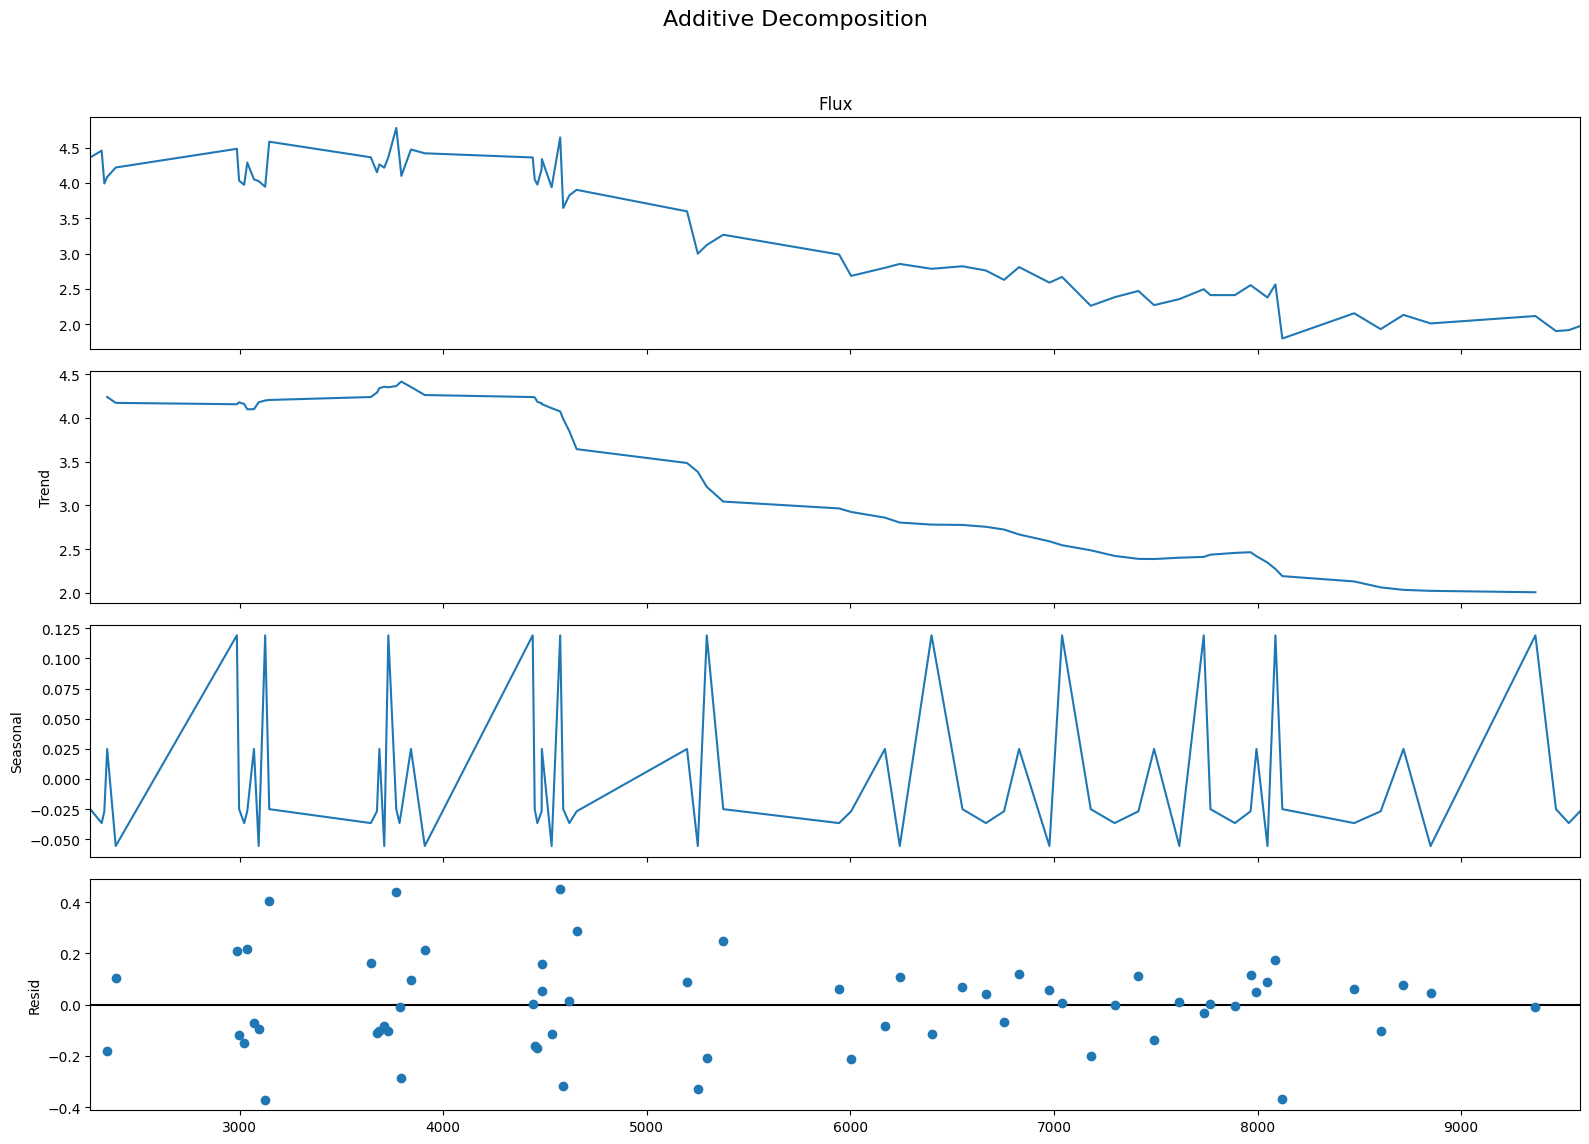

In [9]:
tsa.stattools.adfuller(dat_1_20['Flux'])
#plot_pacf(dat_1_5['Flux'])
multiplicative_decomposition = seasonal_decompose(dat_1_20['Flux'], model='additivee', period=6)
plt.rcParams.update({'figure.figsize': (16,12)})
multiplicative_decomposition.plot().suptitle('Additive Decomposition', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

In [10]:
tsa.stattools.kpss(dat_1['Flux'])

(0.7260346239984455,
 0.011178670545595858,
 9,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

Text(0, 0.5, 'Difference')

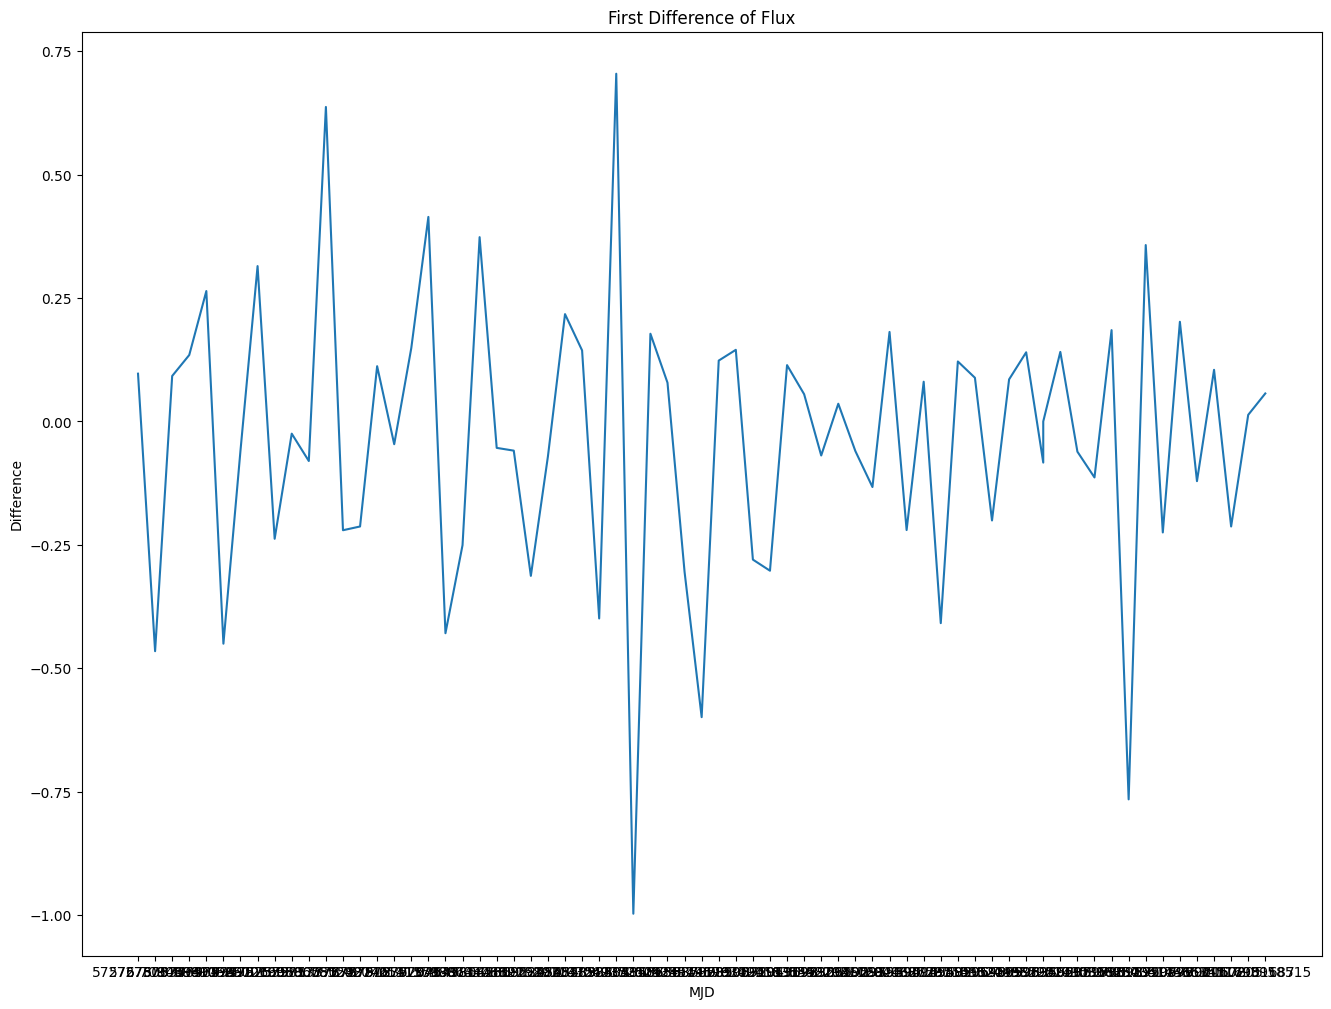

In [11]:
# Ensure Flux is numeric
flux_numeric = pd.to_numeric(dat_1_20['Flux'], errors='coerce')

diff_20 = []
for i in range(1, len(flux_numeric)):
    diff_20.append(flux_numeric.iloc[i] - flux_numeric.iloc[i-1])
diff_20 = pd.Series(diff_20)
diff_20.index = dat_1_20['#MJD'][1:]
plt.plot(diff_20)
plt.title('First Difference of Flux')
plt.xlabel('MJD')
plt.ylabel('Difference')


In [18]:
f=dat_1_20['Flux']
f=pd.to_numeric(f, errors='coerce')
f_e=dat_1_20['e_Flux']
f_e=pd.to_numeric(f_e, errors='coerce')
f_t=dat_1_20['#MJD']
f_t=pd.to_numeric(f_t, errors='coerce')

In [20]:
np.mean(f)
len(f)

69

In [26]:
ti = np.arange(1,len(f)+1)
ti[0]


1